In [85]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

from transformers import BertTokenizer

import tensorflow as tf
from tensorflow.keras import models as keras_models
from tensorflow.keras import layers

In [86]:
df = pd.read_csv("/kaggle/input/datasets/disha808/tweets3/Tweets.csv")

df = df[['text', 'sentiment']]

label_map = {
    'neutral': 0,
    'positive': 1,
    'negative': 2
}

df['sentiment'] = df['sentiment'].map(label_map)

df.dropna(inplace=True)

In [87]:
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased', local_files_only=True)

def tokenize_texts(texts, max_len):
    encoded = tokenizer(
        list(texts),
        padding='max_length',
        truncation=True,
        max_length=max_len,
        return_tensors='np'
    )
    
    return encoded['input_ids']

In [88]:
def build_rnn():
    model = keras_models.Sequential([
        layers.Embedding(8000, 128, input_length=50),
        layers.SimpleRNN(128),
        layers.Dense(3, activation='softmax')
    ])
    return model


def build_lstm():
    model = keras_models.Sequential([
        layers.Embedding(8000, 128, input_length=50),
        layers.LSTM(128),
        layers.Dense(3, activation='softmax')
    ])
    return model


def build_gru():
    model = keras_models.Sequential([
        layers.Embedding(8000, 128, input_length=50),
        layers.GRU(128),
        layers.Dense(3, activation='softmax')
    ])
    return model

In [89]:
models_dict = {
    "RNN": build_rnn,
    "LSTM": build_lstm,
    "GRU": build_gru
}

In [90]:
max_len = 50
X = tokenize_texts(df['text'].values, max_len)
y = df['sentiment'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

histories = {}

for name, model_func in models_dict.items():
    print(f"\nTraining {name}...")

    model = model_func()

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=5,
    batch_size=32,
)

    histories[name] = history


Training RNN...
Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


687/687 ━━━━━━━━━━━━━━━━━━━━ 23s 31ms/step - accuracy: 0.3861 - loss: 1.0961 - val_accuracy: 0.4068 - val_loss: 1.0849
Epoch 2/5
687/687 ━━━━━━━━━━━━━━━━━━━━ 21s 30ms/step - accuracy: 0.3953 - loss: 1.0914 - val_accuracy: 0.3071 - val_loss: 1.1007
Epoch 3/5
687/687 ━━━━━━━━━━━━━━━━━━━━ 21s 31ms/step - accuracy: 0.4000 - loss: 1.0885 - val_accuracy: 0.3801 - val_loss: 1.0902
Epoch 4/5
687/687 ━━━━━━━━━━━━━━━━━━━━ 20s 29ms/step - accuracy: 0.3993 - loss: 1.0887 - val_accuracy: 0.4068 - val_loss: 1.0872
Epoch 5/5
687/687 ━━━━━━━━━━━━━━━━━━━━ 20s 29ms/step - accuracy: 0.4075 - loss: 1.0867 - val_accuracy: 0.4070 - val_loss: 1.0878

Training LSTM...
Epoch 1/5
687/687 ━━━━━━━━━━━━━━━━━━━━ 69s 97ms/step - accuracy: 0.4016 - loss: 1.0894 - val_accuracy: 0.4068 - val_loss: 1.0872
Epoch 2/5
687/687 ━━━━━━━━━━━━━━━━━━━━ 55s 79ms/step - accuracy: 0.4044 - loss: 1.0871 - val_accuracy: 0.4068 - val_loss: 1.0867
Epoch 3/5
687/687 ━━━━━━━━━━━━━━━━━━━━ 54s 79ms/step - accuracy: 0.4070 - loss: 1.0864 - 

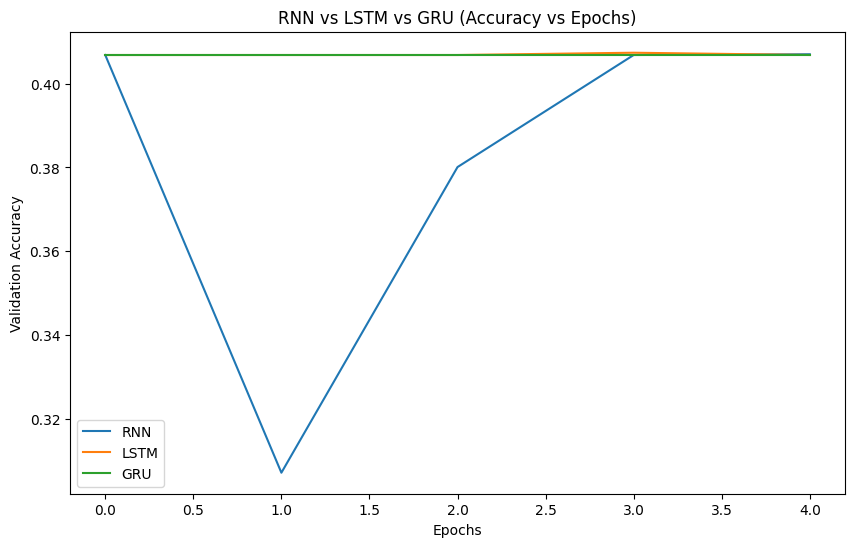

In [91]:
plt.figure(figsize=(10,6))

for name, history in histories.items():
    plt.plot(history.history['val_accuracy'], label=name)

plt.xlabel("Epochs")
plt.ylabel("Validation Accuracy")
plt.title("RNN vs LSTM vs GRU (Accuracy vs Epochs)")
plt.legend()
plt.show()

In [94]:
sequence_lengths = [20, 30, 40, 50]
results = {name: [] for name in models.keys()}

for max_len in sequence_lengths:
    print(f"\nSequence Length: {max_len}")

    X = tokenize_texts(df['text'].values, max_len)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    for name, model_func in models_dict.items():
        print(f"Training {name}...")

        model = model_func()

        model.compile(
            optimizer='adam',
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy']
        )

        model.fit(
            X_train, y_train,
            epochs=3,
            batch_size=32,
            verbose=0
        )

        loss, acc = model.evaluate(X_test, y_test, verbose=0)
        results[name].append(acc)


Sequence Length: 20
Training RNN...
Training LSTM...
Training GRU...

Sequence Length: 30
Training RNN...
Training LSTM...
Training GRU...

Sequence Length: 40
Training RNN...
Training LSTM...
Training GRU...

Sequence Length: 50
Training RNN...
Training LSTM...
Training GRU...


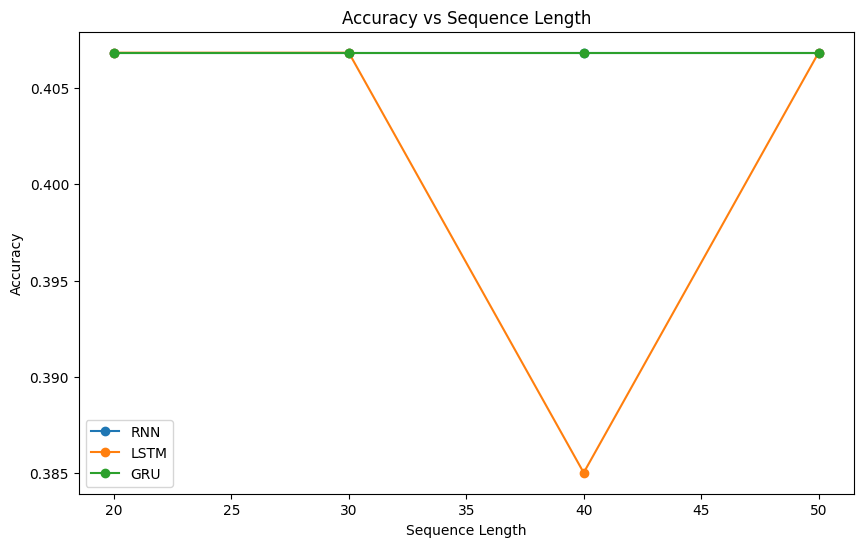

In [95]:
plt.figure(figsize=(10,6))

for name, acc in results.items():
    plt.plot(sequence_lengths, acc, marker='o', label=name)

plt.xlabel("Sequence Length")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Sequence Length")
plt.legend()
plt.show()